# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 01     |  |
| :-------------|:-------------|
| Tim Mekkelholt| 6224687 |
| Ties Langeraar| 6541798 |
| Robert den Haan| 6512186 |

| Planning Groep: 01     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Toepassingen bedenken | 11:45 |
| Mijlpaal 2: Criteria opstellen | 12:45 |
| Mijlpaal 3: kalibratieopstelling ontwerpen | 14:30 |
| Mijlpaal 4: Eerste kalibratie meting gedaan| 15:00 |
| Mijlpaal 5: Meetplan uitgevoerd + simulatie | 15:45 |
| Mijlpaal 6: Iteratie waar nodig + conclusie | 16:30 | 
| Mijlpaal 7: Afronden, opruimen en feedback | 17:30 |
| Pauze 1| 12:45-13:30 |
| Pauze 2| Tijdspanne |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](1000035360.jpg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtmeter | keukenweegschaal | Moet massa's van 0 tot 1 kg kunnen meten |
|krachtmeter | keukenweegschaal | De onzekerheid moet lager zijn dan 0.005 kg |
| Krachtmeter | keukenweegschaal | De sensor moet een gewicht van 5 kg aankunnen zonder te breken |
| Krachtmeter | keukenweegschaal | De massa moet in zijn geheel op een oppervlakte van 1 dm^2 kunnen rusten |
| Temperatuur | Thermostaat| De sensor moet van 10 tot 30 graden celsius kunnen meten |
| Temperatuur | Thermostaat | De onzekerheid moet lager zijn dan 0.3 graden celsius |
| Temperatuur | Thermostaat | De omgevingstemperatuur moet tussen -5 en 50 graden celsius zijn | 
| Lichtsensor | Aanpassing felheid beeldscherm | De sensor moet lichtintensiteiten kunnen meten van 1 tot 1000 lux |
| Lichtsensor | Aanpassing felheid beeldscherm | Onzekerheid van 10% |

Groep 01 heeft gekozen voor de Lichtsensor

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
De meetopstelling bestaat uit een lichtsensor, die via een kort cirquit is aangesloten op een arduino board. De telefoon dient als calibratiemiddel door de lichtintensiteit met de app phyphox te meten. 
![Alt](cirquit.jpeg "schematische tekening cirquit")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
Lichtintensiteit (lux)
2. Over welk bereik ga je deze variabelen veranderen? 
1 tot 1000 lux
3. Wat ga je allemaal meten? 
Lichtintensiteit met de sensor en met telefoon + Schommellingen in lichtintensiteit. Door de lichtinval in de opstelling systematisch te veranderen 
4. Hoeveel metingen ga je doen? 
10 metingen 2 herhalingen. De 10 metingen zijn lineair verdeeld over de range van 1 naar 1000 lux
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
Ja


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Foto 1 is de opstelling met de sensoren te zien. In foto 2 is de grafiek te zien waar de lichtintensiteit in bits afgelezen kon worden. De lichtintensiteit van de telefoon wordt op het scherm in de doos tegelijk afgelezen
 ![Alt](Opstelling1.jpeg "meetopstelling ")
 ![Alt](Opstelling2.jpeg)

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#meetgegevens
data_arduino = np.array([21.5, 555, 722.5, 735, 790, 905, 620, 687.5, 750, 782.5, 805, 852.5, 852.5,24,110,350,122.5,435,126.5,103.5])
onzekerheid_arduino = np.array([1.5, 20, 27.5, 30, 20, 10, 20, 17.5, 20, 22.5, 20, 12.5, 12.5,2,10,10,2.5,15,8.5,5.5])
data_telefoon = np.array([1,70,194,214,246,1061,80,131,218,365,369,442,469,1,6,24,4,20,10,3])
onzekerheid_telefoon = np.array([0.5,2,3,2,3,6,1,1,2,4,3,4,5,0.5,0.5,1,0.5,1,1,0.5])


[ 0.04161245  1.0111654  22.9926849 ]


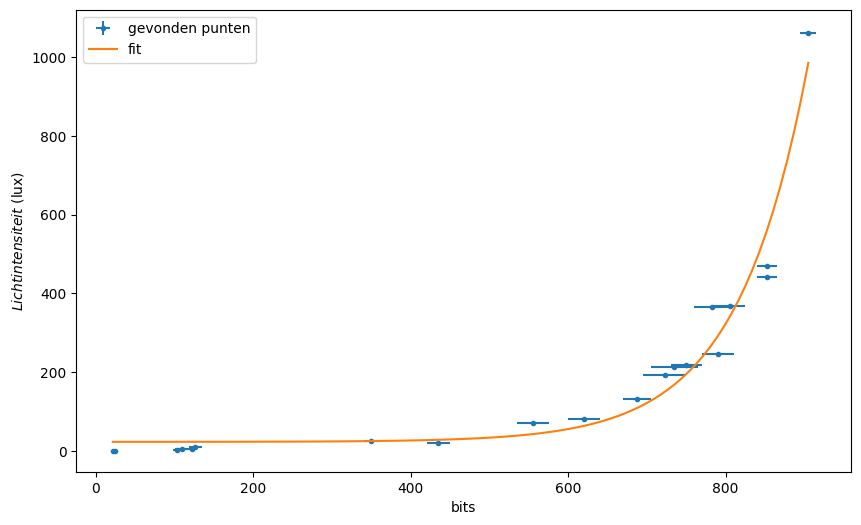

In [2]:
# Plot hier de meting en fit een lijn door de metingen.

def testfit(x, a, b,c):
    return a * b ** x + c

p0 = [1, 1, 0]

vals, covs = curve_fit(testfit, data_arduino, data_telefoon, p0=p0,)
x_fit = np.linspace(min(data_arduino), max(data_arduino), 100)
print(vals)

plt.figure(figsize=(10, 6))
plt.errorbar(data_arduino, data_telefoon, xerr=onzekerheid_arduino , yerr=onzekerheid_telefoon, label = 'gevonden punten', fmt='.')
plt.errorbar(x_fit, testfit(x_fit, *vals), label = 'fit', fmt='-')
plt.xlabel('bits')
plt.ylabel('$Lichtintensiteit$ (lux)')
plt.legend()
plt.show()


## *Opdracht 7*: Iteratie nodig?

Er zijn meerdere iteraties geweest. De in de eerste opstelling werd er nog geen afscherming zoals een doos gebruikt. Dit zorgde voor grote afwijkingen door effecten van de omgeving. 

Daarna hebben wij de doos gebruikt om deze effecten te verminderen.

Als laatste versie zijn stokjes gebruikt om de opening van de doos stabiel te houden en daarmee de onzekerheid nog verder te verlagen.

## *Opdracht 8*: Conclusie, leerdoel
De data laat een duidelijk exponentieel verband zien tussen de waarde in bits en de waarde in lux.
De sensor is wel in staat de vooraf gestelde range uit de criteria van 1 tot 1000 lux te meten. Echter blijkt de sensor niet geschikt voor de toepassing.
Uit de curvefit blijkt de sensor een onzekerheid te hebben van 25%. De criteria gaf een maximale onzekerheid van 10%, wat de sensor niet geschikt maakt.


## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
De meetopstelling bestaat uit een lichtsensor, die via een kort cirquit is aangesloten op een arduino board. De telefoon dient als calibratiemiddel door de lichtintensiteit met de app phyphox te meten. 
![Alt](cirquit.jpeg "schematische tekening cirquit")

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Foto 1 is de opstelling met de sensoren te zien. In foto 2 is de grafiek te zien waar de lichtintensiteit in bits afgelezen kon worden. De lichtintensiteit van de telefoon wordt op het scherm in de doos tegelijk afgelezen
 ![Alt](Opstelling1.jpeg "meetopstelling ")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtmeter | keukenweegschaal | Moet massa's van 0 tot 1 kg kunnen meten |
|krachtmeter | keukenweegschaal | De onzekerheid moet lager zijn dan 0.005 kg |
| Krachtmeter | keukenweegschaal | De sensor moet een gewicht van 5 kg aankunnen zonder te breken |
| Krachtmeter | keukenweegschaal | De massa moet in zijn geheel op een oppervlakte van 1 dm^2 kunnen rusten |
| Temperatuur | Thermostaat| De sensor moet van 10 tot 30 graden celsius kunnen meten |
| Temperatuur | Thermostaat | De onzekerheid moet lager zijn dan 0.3 graden celsius |
| Temperatuur | Thermostaat | De omgevingstemperatuur moet tussen -5 en 50 graden celsius zijn | 
| Lichtsensor | Aanpassing felheid beeldscherm | De sensor moet lichtintensiteiten kunnen meten van 1 tot 1000 lux |
| Lichtsensor | Aanpassing felheid beeldscherm | Onzekerheid van 10% |

Groep 01 heeft gekozen voor de Lichtsensor

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 01     |  |
| :-------------|:-------------|
| Tim Mekkelholt| 6224687 |
| Ties Langeraar| 6541798 |
| Robert den Haan| 6512186 |

| Planning Groep: 01     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Toepassingen bedenken | 11:45 |
| Mijlpaal 2: Criteria opstellen | 12:45 |
| Mijlpaal 3: kalibratieopstelling ontwerpen | 14:30 |
| Mijlpaal 4: Eerste kalibratie meting gedaan| 15:00 |
| Mijlpaal 5: Meetplan uitgevoerd + simulatie | 15:45 |
| Mijlpaal 6: Iteratie waar nodig + conclusie | 16:30 | 
| Mijlpaal 7: Afronden, opruimen en feedback | 17:30 |
| Pauze 1| 12:45-13:30 |
| Pauze 2| Tijdspanne |

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Foto 1 is de opstelling met de sensoren te zien. In foto 2 is de grafiek te zien waar de lichtintensiteit in bits afgelezen kon worden. De lichtintensiteit van de telefoon wordt op het scherm in de doos tegelijk afgelezen
 ![Alt](Opstelling1.jpeg "meetopstelling ")
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#meetgegevens
data_arduino = np.array([21.5, 555, 722.5, 735, 790, 905, 620, 687.5, 750, 782.5, 805, 852.5, 852.5,24,110,350,122.5,435,126.5,103.5])
onzekerheid_arduino = np.array([1.5, 20, 27.5, 30, 20, 10, 20, 17.5, 20, 22.5, 20, 12.5, 12.5,2,10,10,2.5,15,8.5,5.5])
data_telefoon = np.array([1,70,194,214,246,1061,80,131,218,365,369,442,469,1,6,24,4,20,10,3])
onzekerheid_telefoon = np.array([0.5,2,3,2,3,6,1,1,2,4,3,4,5,0.5,0.5,1,0.5,1,1,0.5])

## *Opdracht 8*: Conclusie, leerdoel
De data laat een duidelijk exponentieel verband zien tussen de waarde in bits en de waarde in lux.
De sensor is wel in staat de vooraf gestelde range uit de criteria van 1 tot 1000 lux te meten. Echter blijkt de sensor niet geschikt voor de toepassing.
Uit de curvefit blijkt de sensor een onzekerheid te hebben van 25%. De criteria gaf een maximale onzekerheid van 10%, wat de sensor niet geschikt maakt.

